Bộ dữ liệu được dùng thuộc dataset IMDB Dataset of 50K Movie Reviews
Sau khi rút gọn dataset thì dataset còn 10000 mẫu và có 2 nhãn phân loại

Trong file Movie_Reviews.csv có 2 cột là review và sentiment

review: gồm text

sentiment: Là nhãn gồm positive và negative

In [1]:
!pip install tokenizers
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [2]:
# Chuẩn bị và Load dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from scipy.stats import mannwhitneyu
import re

# Load dữ liệu
df = pd.read_csv('/kaggle/input/datasets/tranbao0105/lab-2-3/Movie_Reviews.csv')

# 1. Tính độ dài văn bản
# Số ký tự
df['char_count'] = df['review'].apply(len)
# Số từ (tách theo khoảng trắng cơ bản vì chưa tiền xử lý)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment  char_count  \
0  One of the other reviewers has mentioned that ...  positive        1761   
1  A wonderful little production. <br /><br />The...  positive         998   
2  I thought this was a wonderful way to spend ti...  positive         926   
3  Basically there's a family where a little boy ...  negative         748   
4  Petter Mattei's "Love in the Time of Money" is...  positive        1317   

   word_count  
0         307  
1         162  
2         166  
3         138  
4         230  
sentiment
positive    5028
negative    4972
Name: count, dtype: int64


### Phân tích thống kê văn bản (Text EDA)
1. Phân phối độ dài và Kiểm định Mann-Whitney U
   - Về hình dạng phân phối, ta thấy ở cả phân phối theo số lượng từ và theo ký tự bị lệch phải
   - Phần lớn review tích cực có số lượng từ và ký tự trung bình lần lượt là 230 và 1308
   - Phần lớn review tiêu cực có số lượng từ và ký tự trung bình lần lượt là 233 và 1312
   -> Đa phần review tiêu cực sẽ có độ dài về từ và ký tự dài hơn review tích cực (Dựa theo giá trị Mean)
   -  Với giá trị P-value=0.0051187043 < 0.05 -> có sự khác biệt đáng kể về độ dài giữa 2 lớp
   -  Có outliear xuất hiện
         + Với review tích cực có review có số lượng từ nhiều nhất lên đến 1830, có ký tự nhiều nhất 10363
         + Với review tiêu cực, có review có số lượng từ nhiều nhất là 1316, có ký tự nhiều nhất là 7164
    -> Outlier ở review tiêu cực và tích cực có giá trị số lượng từ và số lượng ký tự đặc biệt lớn so với giá trị mean của chúng, Outliear này là những giá trị nhiễu, có thể làm mô hình overfitting với các giá trị này nếu huấn luyện quá nhiều epoch hoặc làm cho mô hình huấn luyện lâu hơn do gặp các giá trị nhiễu, các review này có thể gây lỗi bộ nhớ hoặc làm loãng đặc trưng của các câu ngắn

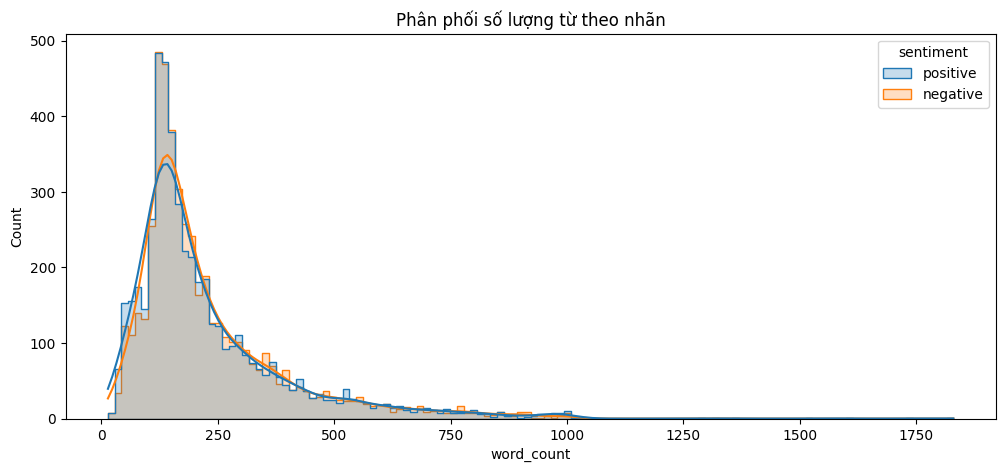

--- Thống kê cho word_count ---
             count        mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   4972.0  232.440668  166.187922  14.0  128.0  175.0  283.0  1316.0
positive   5028.0  229.819014  176.479155  21.0  124.0  169.0  280.0  1830.0


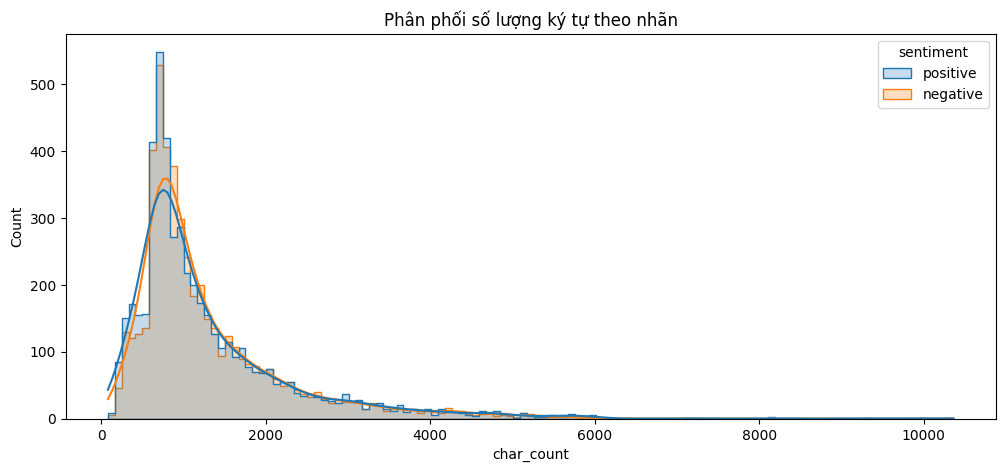

--- Thống kê cho char_count ---
             count         mean          std    min    25%    50%      75%  \
sentiment                                                                   
negative   4972.0  1311.295253   951.672961   80.0  710.0  971.0  1602.00   
positive   5028.0  1307.479515  1024.379033  122.0  683.0  954.0  1596.75   

               max  
sentiment           
negative    7164.0  
positive   10363.0  

Kiểm định Mann-Whitney U cho Word Count:
Statistics=12095528.500, p-value=0.0051187043


In [3]:
def plot_dist(column, title):
    plt.figure(figsize=(12, 5))
    sns.histplot(data=df, x=column, hue='sentiment', kde=True, element="step")
    plt.title(title)
    plt.show()

    # Tính toán thống kê mô tả
    stats = df.groupby('sentiment')[column].describe()
    print(f"--- Thống kê cho {column} ---\n", stats)

# Vẽ phân phối
plot_dist('word_count', 'Phân phối số lượng từ theo nhãn')
plot_dist('char_count', 'Phân phối số lượng ký tự theo nhãn')

# Kiểm định Mann-Whitney U
pos_len = df[df['sentiment'] == 'positive']['word_count']
neg_len = df[df['sentiment'] == 'negative']['word_count']
stat, p = mannwhitneyu(pos_len, neg_len)

print(f"\nKiểm định Mann-Whitney U cho Word Count:")
print(f"Statistics={stat:.3f}, p-value={p:.10f}")

2. Word Cloud, Top-50 và TTR
   - Top 50 từ phổ biến của của cả review tích cực và tiêu cực tương đối giống nhau khi nhìn về top-5 của chúng, cả 2 đều có top 5 là: the, and, a, of, to, điểm giống nhau là chúng đều là stop words -> điều này cho thấy trong việc phân tích text bàn đầu thì nêu bỏ đi các stop words vì chúng không thể hiện được đặc trưng của nhãn, chúng xuất hiện nhiều ở cả 2 nhãn
   - Có sự khác biệt nội dung khi nhìn vào Word Cloud của 2 loại review, ngoài những từ có chủ đề liên quan đến phim thì review tích cực sẽ có các tính từ thể hiện sự tích cực như: great, excelent, best, good, love,... còn những review tiêu cực sẽ có các tính từ liên quan đến sự tiêu cực như: awful, bad, hard, stupid, terible,.... Word cloud này ta không thấy các stop words dù chúng xuất hiện rất nhiều do trong Python tự loại bỏ các stop word bằng danh sách có sẵn của nó khi vẽ word cloud
   - So sánh về giá trị TTR của 2 loại review thì thấy review tích cực có giá trị lớn hơn review tiêu cực, nhưng không đánh kể 0.0797 > 0.0776
     -> Giá trị này tương đối thấp và nằm ở cả 2 loại review cho thấy cách dùng từ của cả 2 nhóm tương đối bình thường, không phong phú, và với một bộ dữ liệu lớn thì có giá trị TTR như thế này cho thấy khi tập dữ liệu lớn hơn nữa thì giá trị token tăng nhanh nhưng số lượng từ mới là type tăng chậm


--- Nhãn: POSITIVE ---
Type-Token Ratio (TTR): 0.0797
Top 5 từ phổ biến: [('the', 64708), ('and', 34014), ('a', 31998), ('of', 30046), ('to', 25488)]


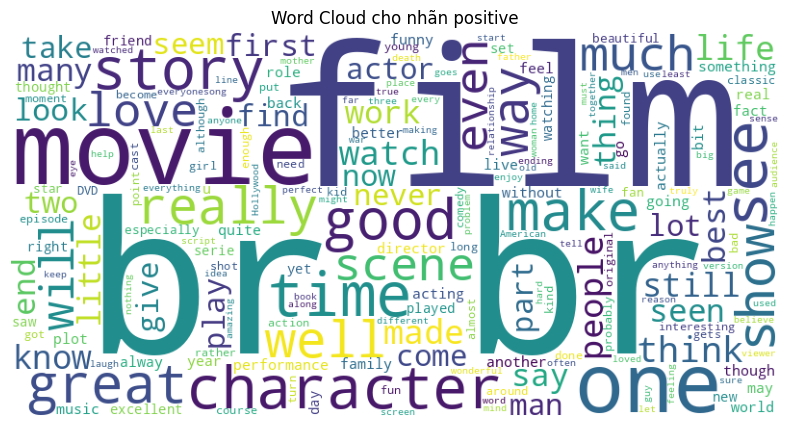


--- Nhãn: NEGATIVE ---
Type-Token Ratio (TTR): 0.0776
Top 5 từ phổ biến: [('the', 63212), ('a', 31297), ('and', 28674), ('of', 27228), ('to', 27183)]


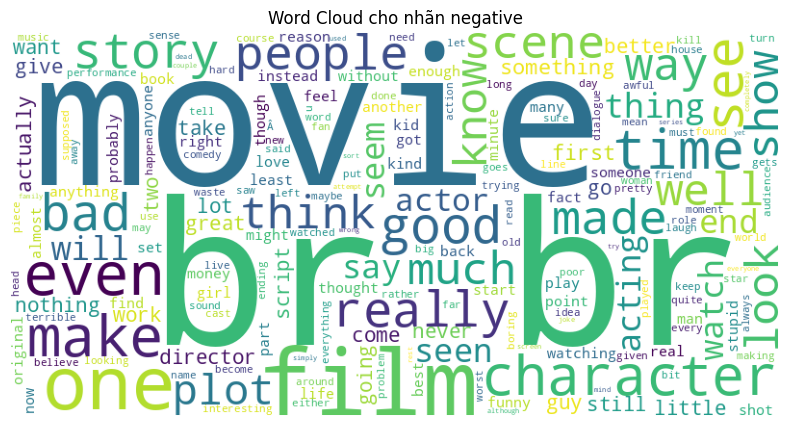

In [4]:
def calculate_ttr(text_list):
    tokens = " ".join(text_list).lower().split()
    types = set(tokens)
    return len(types) / len(tokens) if len(tokens) > 0 else 0

for label in ['positive', 'negative']:
    subset = df[df['sentiment'] == label]['review']
    
    # Tính TTR
    ttr = calculate_ttr(subset)
    print(f"\n--- Nhãn: {label.upper()} ---")
    print(f"Type-Token Ratio (TTR): {ttr:.4f}")
    
    # Top 50 từ
    words = " ".join(subset).lower().split()
    top_50 = Counter(words).most_common(50)
    print(f"Top 5 từ phổ biến: {top_50[:5]}")
    
    # Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(subset))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.title(f"Word Cloud cho nhãn {label}")
    plt.axis('off')
    plt.show()

3. Phân tích phân phối Zipf
   - Đường biểu đồ log-log cho frequency và rank gần như 1 đường thẳng đi xuống, nó tuân theo quy luật Zipf là tần xuất tỉ lể nghịch với thứ hạng của nó -> ngôn ngữ của các bài review vẫn có tính tự nhiên, các từ có thứ hạng 1, 2,... thì tần suất xuất hiện nó càng nhiều nhưng chúng lại là các stop words không mang ý nghĩa, trong khi những từ thể hiện được tính đặc trưng thì tần suất chúng lại thấp -> một cách để khắc phục được điều này là dùng BPE để chuyển đổi các từ đó về dạng gốc, giúp tăng tần suất xuất hiện của chúng lên

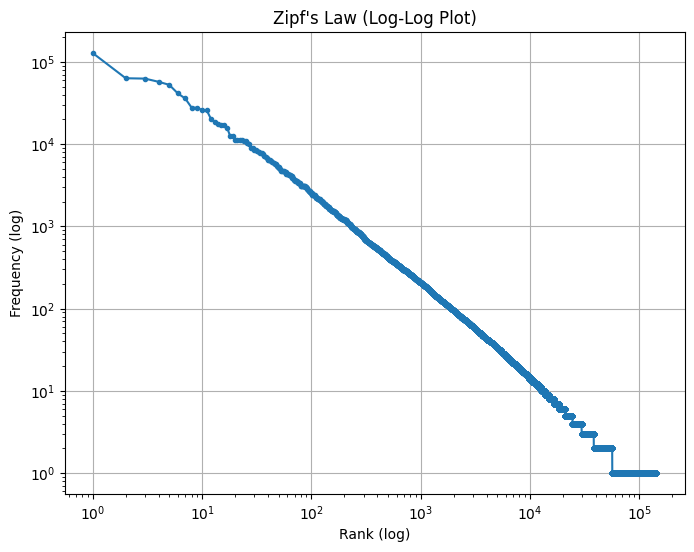

In [5]:
def plot_zipf(text_list):
    words = " ".join(text_list).lower().split()
    counts = Counter(words)
    frequencies = sorted(counts.values(), reverse=True)
    ranks = range(1, len(frequencies) + 1)
    
    plt.figure(figsize=(8, 6))
    plt.loglog(ranks, frequencies, marker=".")
    plt.title("Zipf's Law (Log-Log Plot)")
    plt.xlabel("Rank (log)")
    plt.ylabel("Frequency (log)")
    plt.grid(True)
    plt.show()

plot_zipf(df['review'])

### Kỹ thuật tiền xử lý và phân tích tác động
1. Pipeline chuẩn hóa văn bản, phân tích tỉ lệ từ vựng thay đổi và tác động đến phân phối độ dài văn bản với mỗi bước
   - Lowercase: ta thấy vocab size giảm 15092 và Avg Word Length giữ nguyên so với original, vì khi lowercase thì những từ trước đó được tính là 2 do 1 từ viết hoa, 1 từ viết thường thì giờ đây đã trở thành 1, lowercase thì không xóa từ trong sample nên avg word length không đổi
   - Remove HTML: Nhờ vào việc xóa HTML là xóa từ khỏi sample nên cả vocab size và avg word length đều giảm
   - Remove URL/Tags: tương tự remove HTML nhưng có vẻ giảm không nhiều
   - Remove Special/Num: giảm được cả vocab size nhiều nhất do không chỉ là xóa số, ký tự đặc biệt bình thường mà chỉ cần từ có hay vô tình chứa số hoặc ký tự đặt biệt, nó xóa ký tự đặt biệt đó đi và từ mới nhận được là 1 từ đã có trong vocabulary nên số lượng giảm xuống đáng kể, đặc biệt là giá trị avg word length không giảm mà lại tăng là do có 1 số từ đặc biệt như don't, well-know,... khi bỏ ký tự đặt biệt thì nó biến từ 1 ành 2 từ dẫn đến độ dài tăng
   - Normalize Whitespace: không giảm được gí trị của thuộc tính nào cả do trong code ta dùng hàm split(), hàm này bỏ qua các khoảng trắng dư thừa rồi, nên trong thực tên bước normalize quan trọng do nó làm gọn được string
   => Ta thấy xóa số, ký tự đặc biệt là giảm được Vocab size và cả Avg word length nhiều nhất nhưng việc này cũng không hoàn toàn có lợi, dù có thể xóa cá dấu câu, ký hiệu đặc biệt, những từ có trong Vocabulary rồi nhưng lỡ dính với số hoặc ký tự đặc biệt nên trở thành 1 từ mới, những từ này không mang lại thông tin quan trọng nên xóa đi là tốt nhưng cũng có 1 số trường hợp mang thông in đặc trưng rất rõ (ví dụ như: "10/10", "A+", ...) nhưng những từ này cũng không dễ để ta xác định thành 1 tập hợp, từ đó mà có thể giữ lại. Trong trường hợp này ta có lượng chọn đánh đổi là xóa chúng để vocab size nhỏ hơn, ít nhiễu hơn.

In [6]:
import re
import pandas as pd
import numpy as np

# Tạo bản sao dữ liệu để xử lý
df_clean = df.copy()

def get_stats(text_series):
    # Tính số từ vựng duy nhất và độ dài trung bình (tính theo số từ)
    words = " ".join(text_series).split()
    vocab_size = len(set(words))
    avg_len = np.mean(text_series.apply(lambda x: len(str(x).split())))
    return vocab_size, avg_len

stats = []
stats.append(('Original', *get_stats(df_clean['review'])))

# 1. Lowercase
df_clean['step1'] = df_clean['review'].str.lower()
stats.append(('1. Lowercase', *get_stats(df_clean['step1'])))

# 2. Xóa HTML (VD: <br />)
df_clean['step2'] = df_clean['step1'].apply(lambda x: re.sub(r'<.*?>', ' ', x))
stats.append(('2. Remove HTML', *get_stats(df_clean['step2'])))

# 3. Xóa URL/Mention/Hashtag
df_clean['step3'] = df_clean['step2'].apply(lambda x: re.sub(r'http\S+|www\S+|@\w+|#\w+', '', x))
stats.append(('3. Remove URL/Tags', *get_stats(df_clean['step3'])))

# 4. Xóa ký tự đặc biệt và số (Chỉ giữ lại a-z và khoảng trắng)
df_clean['step4'] = df_clean['step3'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
stats.append(('4. Remove Special/Num', *get_stats(df_clean['step4'])))

# 5. Chuẩn hóa khoảng trắng
df_clean['cleaned_text'] = df_clean['step4'].apply(lambda x: " ".join(x.split()))
stats.append(('5. Normalize Whitespace', *get_stats(df_clean['cleaned_text'])))

# Tạo DataFrame
stats_df = pd.DataFrame(stats, columns=['Step', 'Vocab Size', 'Avg Word Length'])

# Thêm cột tính toán sự thay đổi so với bước liền trước
stats_df['Vocab Change'] = stats_df['Vocab Size'].diff().fillna(0).astype(int)
stats_df['Avg Length Change'] = stats_df['Avg Word Length'].diff().fillna(0).round(2)

# Sắp xếp lại thứ tự cột cho dễ nhìn
stats_df = stats_df[['Step', 'Vocab Size', 'Vocab Change', 'Avg Word Length', 'Avg Length Change']]
print(stats_df)

                      Step  Vocab Size  Vocab Change  Avg Word Length  \
0                 Original      158391             0         231.1225   
1             1. Lowercase      143299        -15092         231.1225   
2           2. Remove HTML      135324         -7975         228.7986   
3       3. Remove URL/Tags      135251           -73         228.7909   
4    4. Remove Special/Num       51727        -83524         234.0299   
5  5. Normalize Whitespace       51727             0         234.0299   

   Avg Length Change  
0               0.00  
1               0.00  
2              -2.32  
3              -0.01  
4               5.24  
5               0.00  


2. So sánh chiến lược Tokenization
   - Nhìn vào kết quả kích thước từ vựng,, tỉ lệ OOV trên tập test, độ dài chuỗi token trung bình, xét với level của charater, word, sentence ta có thể đưa ra 1 số nhận xét như sau
     + Kích thước từ vựng (Vocab Size):
            + Ở charater-level là nhỏ nhất vì đây là số lượng loại chữ cái trên tập train, 26 ứng với toàn bộ chữ cái trên bảng chữ cái tiếng anh, nhưng việc này làm mất hoàn toàn ngư nghĩa của chúng
           + Lớn hơn lần lượt là của word-level và sentence-level, với chúng là số lượng từ khác nhau, số lượng câu khác nhau trên tập train, số lượng câu khác nhau là lớn nhất vì hầu như không có câu nào là giống hoàn toàn câu nào.
     + Tỉ lệ OOV trên tập test:
            + Nhỏ nhất là của charater-level vì không có chữ cái nào khác bảng chữ cái tiếng anh mà nằm trong tập test
           + Lớn hơn là word-level với giá trị 1.24%, đây cũng là 1 giá trị khá tốt khi trên tập test chỉ có hơn 1% từ không nằm ở tập train
           + Còn lớn nhất là sentence-level cũng như đã nói ở trên vì hầu như mọi câu không giống nhau hoàn toàn
     + Độ dài chuỗi token trung bình (Avg Seq Length):
           + Nhỏ nhất là sentence-level vi mỗi sample có số lượng câu không quá lớn nên trung bình của chúng trên tập train chỉ là 10.6
           + Khác với nó, word-level và charater-level lớn hơn rất nhiều do 1 sample có thể có nhiều từ, rất nhiều chữ
     => Khi 3 level trên đều có khuyết điểm của mình thì chiến lượt tokenization  subword lại cho kết quả rất tốt với Vocab size, OOV rate, Avg Seq Length lần lượt là 4974, 0%, 277.4, vì thế nếu được lựa chọn thì đây là chiến lượt tốt nhất nhờ nguyên tắc của nó là từ phổ biến thì giữ nguyên, từ hiếm thì được cắt nhỏ ra

In [7]:
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize, sent_tokenize
from tokenizers import Tokenizer, models, pre_tokenizers, trainers

# Chia Train/Test (Dùng cột đã clean ở bước a)
X_train, X_test = train_test_split(df_clean['cleaned_text'], test_size=0.2, random_state=42)

def eval_tokenization(name, train_tokens_list, test_tokens_list):
    # Tạo từ điển từ tập Train
    train_vocab = set([token for seq in train_tokens_list for token in seq])
    vocab_size = len(train_vocab)
    
    # Tính OOV trên tập Test
    test_tokens = [token for seq in test_tokens_list for token in seq]
    if len(test_tokens) == 0: oov_rate = 0
    else:
        oov_count = sum(1 for token in test_tokens if token not in train_vocab)
        oov_rate = oov_count / len(test_tokens)
        
    # Tính độ dài chuỗi trung bình
    avg_len = np.mean([len(seq) for seq in train_tokens_list])
    
    print(f"--- {name} ---")
    print(f"Vocab size: {vocab_size:,} | OOV Rate: {oov_rate*100:.2f}% | Avg Seq Length: {avg_len:.1f}")

# 1. Word-level (NLTK)
train_word = [word_tokenize(text) for text in X_train]
test_word = [word_tokenize(text) for text in X_test]
eval_tokenization("Word-level (NLTK)", train_word, test_word)

# 2. Sentence-level (Dùng văn bản gốc để thấy rõ câu, vì text clean mất dấu chấm)
train_sent = [sent_tokenize(text) for text in df_clean.loc[X_train.index, 'review']]
test_sent = [sent_tokenize(text) for text in df_clean.loc[X_test.index, 'review']]
eval_tokenization("Sentence-level", train_sent, test_sent)

# 3. Character-level
train_char = [list(text.replace(" ", "")) for text in X_train]
test_char = [list(text.replace(" ", "")) for text in X_test]
eval_tokenization("Character-level", train_char, test_char)

# 4. Subword (BPE HuggingFace)
# Khởi tạo mô hình BPE
tokenizer_bpe = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer_bpe.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.BpeTrainer(vocab_size=5000, special_tokens=["[UNK]"])
# Train BPE trên tập Train
tokenizer_bpe.train_from_iterator(X_train, trainer=trainer)

train_bpe = [tokenizer_bpe.encode(text).tokens for text in X_train]
test_bpe = [tokenizer_bpe.encode(text).tokens for text in X_test]
eval_tokenization("Subword (BPE - Vocab 5000)", train_bpe, test_bpe)

--- Word-level (NLTK) ---
Vocab size: 47,054 | OOV Rate: 1.24% | Avg Seq Length: 234.2
--- Sentence-level ---
Vocab size: 83,717 | OOV Rate: 97.85% | Avg Seq Length: 10.6
--- Character-level ---
Vocab size: 26 | OOV Rate: 0.00% | Avg Seq Length: 1015.3



--- Subword (BPE - Vocab 5000) ---
Vocab size: 4,974 | OOV Rate: 0.00% | Avg Seq Length: 277.4


3. Loại bỏ Stop words và phân tích (Kích thước, MI, Hiệu năng)
   - Sau khi loại bỏ stop words, vocab giảm đi 144 từ và MI trung bình cũng giảm, đại lượng MI thể hiện thông tin mà 1 từ đóng góp vào nhãn nên nhưng not, no, very,... bỏ những từ này đôi lúc ảnh hưởng rất nhiều đến việc phân loại nhãn vì chúng có giá trị MI cao
   - Accuracy sau khi bỏ stop words có tăng do stop mang thông tin không giá trị mà lại có số lượng rất lớn, bỏ đi chúng giúp mô hình tập trung vào các từ có ý nghĩa quan trọng hơn
   - Việc loại bỏ stop word đôi khi cũng không làm tốt kết quả theo hướng ta muốn nhưng việc loại bỏ chúng có thể làm việc tính toán nhanh hơn

In [8]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

# Chuẩn bị nhãn
y = df_clean['sentiment'].map({'positive': 1, 'negative': 0})
texts = df_clean['cleaned_text']

# Lấy danh sách stop words của NLTK
stop_words = set(stopwords.words('english'))

# Hàm loại bỏ stop words
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

texts_no_stop = texts.apply(remove_stopwords)

def analyze_representation(text_data, y, name):
    # Biến đổi thành Ma trận đếm (BoW)
    vectorizer = CountVectorizer() 
    X = vectorizer.fit_transform(text_data)
    
    vocab_size = len(vectorizer.vocabulary_)
    
    print(f"Đang tính Mutual Information cho: {name}...") 
    
    # Tính MI trung bình trên toàn bộ dữ liệu
    mi_scores = mutual_info_classif(X, y)
    avg_mi = np.mean(mi_scores)
    
    # Tính hiệu năng Naive Bayes bằng 5-fold CV
    nb = MultinomialNB()
    cv_scores = cross_val_score(nb, X, y, cv=5, scoring='accuracy')
    avg_acc = np.mean(cv_scores)
    
    print(f"--- {name} ---")
    print(f"Vocab Size: {vocab_size:,}")
    print(f"Average MI: {avg_mi:.6f}")
    print(f"Naive Bayes 5-fold CV Accuracy: {avg_acc:.4f}\n")

# Chạy phân tích
analyze_representation(texts, y, "Trạng thái: GIỮ LẠI Stop Words")
analyze_representation(texts_no_stop, y, "Trạng thái: ĐÃ LOẠI BỎ Stop Words")

Đang tính Mutual Information cho: Trạng thái: GIỮ LẠI Stop Words...
--- Trạng thái: GIỮ LẠI Stop Words ---
Vocab Size: 51,701
Average MI: 0.000149
Naive Bayes 5-fold CV Accuracy: 0.8384

Đang tính Mutual Information cho: Trạng thái: ĐÃ LOẠI BỎ Stop Words...
--- Trạng thái: ĐÃ LOẠI BỎ Stop Words ---
Vocab Size: 51,557
Average MI: 0.000144
Naive Bayes 5-fold CV Accuracy: 0.8495



4. Stemming, Lemmatization và so sánh Collision Rate, hiệu năng
    - Từ dataset có 51717 từ, Stemming và Lemmatization sẽ cắt từ về từ gốc
  
      + Với 2 phương pháp Stemming thì cắt giảm từ rất nhiều, còn 35001 gốc từ với Porter và 34557 với Snowball nhưng kèo theo đó lại là tỉ lệ collision rate rất cao 32.34% và 33.19%, đây là tỉ lệ góm nhiều từ về 1 gốc, trong một số trường hợp nó có thể phù hợp nhưng phần lớn thì nó sai, làm mất đi nghĩa đúng của từ gốc, phương pháo này tuân theo rule nên cắt nhỏ từ đi sẽ rất thô bạo, không phù hợp, trong số những từ bị loại bỏ, có thể có nhiều từ đúng ra là vẫn phải giữ lại, một số từ khi bị cắt nhỏ ra do luật cho kết quả là từ không có nghĩa
      + Với phương pháp Lemmatization, nhờ nó dùng từ điển WordNet nên từ được chuyển về từ gốc là chính xác, luôn có nghĩa, với kết quả 10.67% cho collision rate và còn 46209 gốc từ, số gốc từ ở đây ứng đúng với từ điển và tỉ lệ collision này có ý nghĩa là các từ khác nhau đó thật sự cùng gốc từ

   - So sánh về Accuracy của Logisstic Regression với 3 phương pháp trên và phần word gốc thì thấy các phương pháp không làm tăng được Accuracy mà thậm gì còn giảm (Trong đó Lemmazation là giảm ít nhần còn Porter là giảm nhiều nhất), có thể do ngữ pháp tiếng anh đơn giản...

In [9]:
import pandas as pd
import numpy as np
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import nltk

# Khởi tạo các công cụ
porter = PorterStemmer()
snowball = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

# Lấy 10,000 từ phổ biến nhất trong tập dữ liệu để tính Collision Rate (tránh tính trên toàn bộ chạy quá lâu)
all_words = " ".join(df_clean['cleaned_text']).split()
#unique_words = list(set(all_words))[:10000] 
unique_words = list(set(all_words))

def calculate_collision_rate(words, method_func):
    """Tính tỉ lệ các từ ban đầu khác nhau nhưng bị biến đổi thành CÙNG MỘT dạng"""
    mapped_words = [method_func(w) for w in words]
    original_count = len(words)
    unique_mapped_count = len(set(mapped_words)) # Số gốc từ duy nhất sau khi biến đổi
    
    # Collision Rate = (Số từ ban đầu - Số gốc từ duy nhất) / Số từ ban đầu
    # Tỉ lệ này càng cao nghĩa là phương pháp gộp càng nhiều từ khác nhau thành 1
    collision_rate = (original_count - unique_mapped_count) / original_count
    return collision_rate, unique_mapped_count

def evaluate_classification(text_data, y, name):
    # Dùng TF-IDF đơn giản để đánh giá
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(text_data)
    
    # Logistic Regression 5-fold CV
    lr = LogisticRegression(max_iter=1000)
    scores = cross_val_score(lr, X, y, cv=5, scoring='accuracy')
    
    print(f"--- {name} ---")
    print(f"LR 5-fold Accuracy: {np.mean(scores):.4f} (std: {np.std(scores):.4f})\n")

print("Dataset có ", len(unique_words))
# 1. Tính Collision Rate
print("--- Collision Rate trên toàn dataset ---")
cr_porter, count_porter = calculate_collision_rate(unique_words, porter.stem)
print(f"Porter Stemmer: {cr_porter*100:.2f}% (Còn {count_porter} gốc từ)")

cr_snowball, count_snowball = calculate_collision_rate(unique_words, snowball.stem)
print(f"Snowball Stemmer: {cr_snowball*100:.2f}% (Còn {count_snowball} gốc từ)")

# Lemmatizer mặc định coi từ là danh từ (noun), nếu muốn chính xác phải thêm tag POS (verb, adj...)
cr_lemma, count_lemma = calculate_collision_rate(unique_words, lemmatizer.lemmatize)
print(f"WordNet Lemmatizer: {cr_lemma*100:.2f}% (Còn {count_lemma} gốc từ)\n")

# 2. Tạo tập dữ liệu mới và Đánh giá hiệu năng (chạy mất khoảng 1-2 phút)
print("Đang chuẩn bị dữ liệu Stemming/Lemmatization...")

sample_texts = df_clean['cleaned_text']
sample_y = df_clean['sentiment'].map({'positive': 1, 'negative': 0})

texts_porter = sample_texts.apply(lambda x: " ".join([porter.stem(w) for w in x.split()]))
texts_snowball = sample_texts.apply(lambda x: " ".join([snowball.stem(w) for w in x.split()]))
texts_lemma = sample_texts.apply(lambda x: " ".join([lemmatizer.lemmatize(w) for w in x.split()]))

print("Đang đánh giá hiệu năng...")
evaluate_classification(sample_texts, sample_y, "1. Original Cleaned Text")
evaluate_classification(texts_porter, sample_y, "2. Porter Stemmer")
evaluate_classification(texts_snowball, sample_y, "3. Snowball Stemmer")
evaluate_classification(texts_lemma, sample_y, "4. WordNet Lemmatizer")

Dataset có  51727
--- Collision Rate trên toàn dataset ---
Porter Stemmer: 32.34% (Còn 35001 gốc từ)
Snowball Stemmer: 33.19% (Còn 34557 gốc từ)
WordNet Lemmatizer: 10.67% (Còn 46209 gốc từ)

Đang chuẩn bị dữ liệu Stemming/Lemmatization...
Đang đánh giá hiệu năng...
--- 1. Original Cleaned Text ---
LR 5-fold Accuracy: 0.8755 (std: 0.0058)

--- 2. Porter Stemmer ---
LR 5-fold Accuracy: 0.8740 (std: 0.0092)

--- 3. Snowball Stemmer ---
LR 5-fold Accuracy: 0.8741 (std: 0.0083)

--- 4. WordNet Lemmatizer ---
LR 5-fold Accuracy: 0.8754 (std: 0.0065)



5. Vector hóa (BoW, TF-IDF, Word2Vec) và không gian đặc trưng (t-SNE, Silhouette)
    - Dùng 3 phương pháp Vector hóa là BoW, TF-IDF, Word2Vec và so sánh các giá trị sparsity, Consine Similarity, Silhouette ta thấy
      + Xét Sparsity
          + BoW và IF-IDF có Sparsity rất lớn là 91.12% và 89.41%, đây là do 1 sample là review thì không quá dài như sparsity lại xét các từ trên sample đó với tất cả các loại từ của dataset -> phần lớn từ có trong dataset mà không có trong sample, nếu ma trận chứa nhiều số 0 như vậy thì việc tính toán sẽ tốn chi phí và chậm
            + Word2Vec thì có Sparsity = 0% do nó biểu diễn lại các chữ thành vector có kích thước là 100 là những con số và hầu hết là khác 0 nên sparsity mới bằng 0%
        + Xét giá trị Cosine Similarity
            + Consine Similarity của Bow ở khác lớp là 0.5878 lại cao hơn cừng lớp là 0.5716, do BoW là đếm tần suất của các từ nên cả review tích cực hay tiêu cực đều chứa các từ chung chung, làm BoW nhầm tưởng và không cho kết quả tốt
            +  TF-IDF thì đỡ hơn khi giá trị ở cùng lớp lớn hơn khác lớp, giá trị consine similarity cũng giảm xuống khoảng ~0.25 với 0.2597 ở cùng lớp và 0.2368 ở khác lớp là do TF-IDF đã giảm trọng số các từ xuất hiện phổ biến ở tài liệu, tăng ảnh hưởng của các từ đặc trưng
            +  Cosine Similarity rất cao vào khoảng 0.99 ở cả 2 trường hợp do Word2Vec lấy trung bình vector của các từ trong văn bản, giá trị này tương đối giống nhau ở các bài review nên làm tưởng các bài review giống nhau dù chúng khác về sentiment, Word2Vec thể hiện tốt được nghĩa cuar 1 từ riêng lẻ nhưng khi tính trung bình rất nhiều vector thứ tự, ngữ pháp hay các từ mang giá trị thể hiện cảm xúc bị mờ đi
        + Xét Silhouette và đồ thị t_SNE
            + Silhouette của cả 3 phương pháp đều rất thấp với Word2Vec > IF-IDF > BoW nhưng chỉ trong khoảng từ 0.0018 -> 0.0172, cùng với đồ thị t-SNE có các điểm khác lớp vẫn đề lên nhau không phân cụm rõ ràng thì thấy phương pháp này chưa tốt -> sentiment là một đặc trưng khó phân tách, không thể dùng các phương pháp trên để gom cụm

Đang chạy BoW...
--- Bag of Words (BoW) ---
Kích thước ma trận: 1000x1000 | Sparsity: 91.12%
Sim cùng lớp (Pos-Pos): 0.5578 | Sim khác lớp (Pos-Neg): 0.5615
Silhouette Score: 0.0018



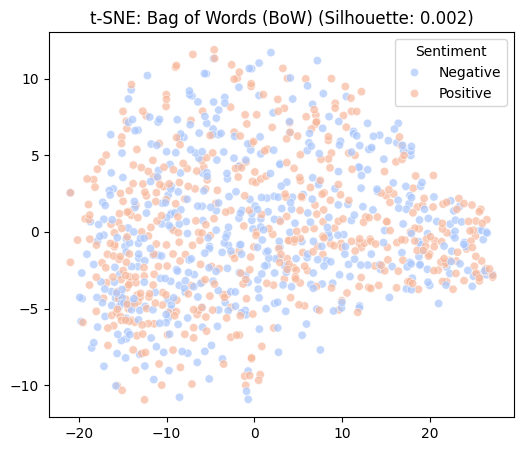

Đang chạy TF-IDF...
--- TF-IDF (1,2,3-grams) ---
Kích thước ma trận: 1000x1000 | Sparsity: 89.41%
Sim cùng lớp (Pos-Pos): 0.2542 | Sim khác lớp (Pos-Neg): 0.2246
Silhouette Score: 0.0030



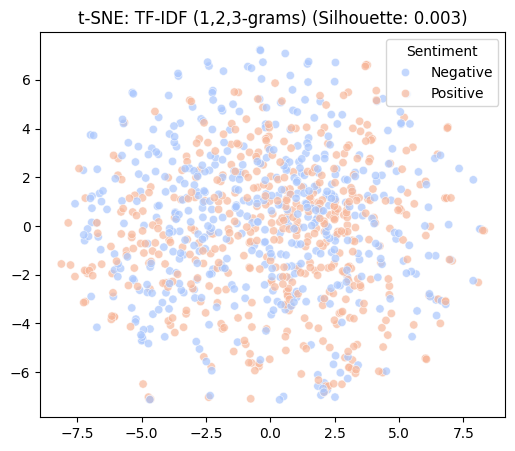

Đang chạy Word2Vec...
--- Word2Vec (Average) ---
Kích thước ma trận: 1000x100 | Sparsity: 0.00%
Sim cùng lớp (Pos-Pos): 0.9923 | Sim khác lớp (Pos-Neg): 0.9924
Silhouette Score: 0.0167



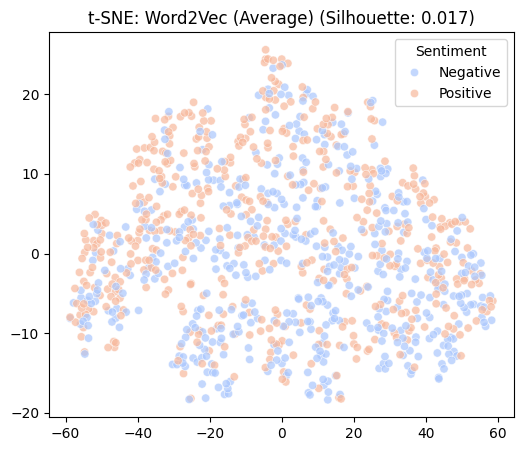

In [10]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
import numpy as np

# Lấy 1000 sample để trực quan hóa nhanh
subset_df = df_clean.sample(1000, random_state=42)
X_texts = subset_df['cleaned_text']
y_labels = subset_df['sentiment'].map({'positive': 1, 'negative': 0})

def analyze_vectorization(X_matrix, y, name):
    # (i) Số chiều và độ thưa
    n_samples, n_features = X_matrix.shape
    
    # Tính sparsity (Kiểm tra xem X_matrix có phải là sparse matrix không)
    if hasattr(X_matrix, "nnz"):
        sparsity = 1.0 - (X_matrix.nnz / (n_samples * n_features))
    else: # Dành cho Word2Vec (Dense matrix)
        zero_elements = np.count_nonzero(X_matrix == 0)
        sparsity = zero_elements / (n_samples * n_features)
        
    print(f"--- {name} ---")
    print(f"Kích thước ma trận: {n_samples}x{n_features} | Sparsity: {sparsity*100:.2f}%")
    
    # (ii) Cosine Similarity (Cùng lớp vs Khác lớp)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    
    # Lấy tối đa 50 cặp ngẫu nhiên để tính 
    np.random.shuffle(pos_idx); np.random.shuffle(neg_idx)
    min_len = min(50, len(pos_idx), len(neg_idx))
    
    # Phải check hasattr toarray vì Word2Vec bản chất đã là mảng NumPy
    X_to_calc = X_matrix.toarray() if hasattr(X_matrix, "toarray") else X_matrix
    
    same_class_sim = cosine_similarity(X_to_calc[pos_idx[:min_len]], X_to_calc[pos_idx[min_len:min_len*2]]).mean()
    diff_class_sim = cosine_similarity(X_to_calc[pos_idx[:min_len]], X_to_calc[neg_idx[:min_len]]).mean()
    print(f"Sim cùng lớp (Pos-Pos): {same_class_sim:.4f} | Sim khác lớp (Pos-Neg): {diff_class_sim:.4f}")
    
    # (iii) t-SNE và Silhouette Score (Trực quan hóa)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X_to_calc)
    
    sil_score = silhouette_score(X_to_calc, y)
    print(f"Silhouette Score: {sil_score:.4f}\n")
    
    # TẠO NHÃN MÀU 
    hue_labels = ['Positive' if val == 1 else 'Negative' for val in y]
    
    # Vẽ đồ thị
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=hue_labels, palette='coolwarm', alpha=0.7)
    plt.title(f"t-SNE: {name} (Silhouette: {sil_score:.3f})")
    plt.legend(title='Sentiment')
    plt.show()

# 1. BoW
print("Đang chạy BoW...")
bow = CountVectorizer(max_features=1000)
X_bow = bow.fit_transform(X_texts)
analyze_vectorization(X_bow, y_labels.values, "Bag of Words (BoW)")

# 2. TF-IDF (n-gram 1, 2, 3)
print("Đang chạy TF-IDF...")
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=1000)
X_tfidf = tfidf.fit_transform(X_texts)
analyze_vectorization(X_tfidf, y_labels.values, "TF-IDF (1,2,3-grams)")

# 3. Word2Vec
print("Đang chạy Word2Vec...")
sentences = [text.split() for text in X_texts]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

def document_vector(doc):
    words = [w for w in doc.split() if w in w2v_model.wv]
    if len(words) == 0: return np.zeros(100)
    return np.mean(w2v_model.wv[words], axis=0)

X_w2v = np.array([document_vector(text) for text in X_texts])
analyze_vectorization(X_w2v, y_labels.values, "Word2Vec (Average)")

6. Biểu diễn ngữ nghĩa bằng Sentence Transformer dùng mô hình all-MiniLM-L6-v2
   - Theo t-SNE và Consine Similarity
       + So với IF-IDF thì Sentence Transformer đã nét vector về kích thước bằng 384, về Cosine Similarity thì ở cùng lớp và khác lớp rơi vào khoảng 0.3, silhouette chỉ đạt 0.0085, chưa phân biệt được rõ giữa 2 lớp, theo đồ thị t-SNE thì các review tích cực và tiêu cực vẫn trộn lẫn vào nhau, có thể là do mô hình trên là mô hình hiểu ngữ nghĩa chứ không hiểu về sentiment, có thể do các bài khen chê về cấu trúc vẫn khá giống nhau
    - Theo K-Means Clustering
      + Giá trị Silhouette của Sentence Transformer tăng lên thành 0.0348, gần gắp đôi so với TF-IDF, có thể khi giảm chiều về 384 thì giữa các câu có liên kết, cấu trúc chặt chẽ hơn
    - Theo Linear SVM
        + Khi đưa bài toán về có giám sát, Accuracy của Sentence Transformer tăng lên 79.7%, lớn hơn TF-IDF 3%, vì TF-IDF tách từ từ và chấm điểm nên nó chưa hiểu được ngữ cảnh còn Sentence Transformer dùng Self-Attention và bidirectional, hiểu ngữ cảnh, có thể bắt được các dặc trưng cảm xúc tốt hơn

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đang mã hóa văn bản bằng Sentence Transformer...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Đang thực hiện K-Means Clustering...
K-Means Silhouette (TF-IDF): 0.0181
K-Means Silhouette (Sentence Transformer): 0.0395

Đang vẽ đồ thị các cụm K-Means...


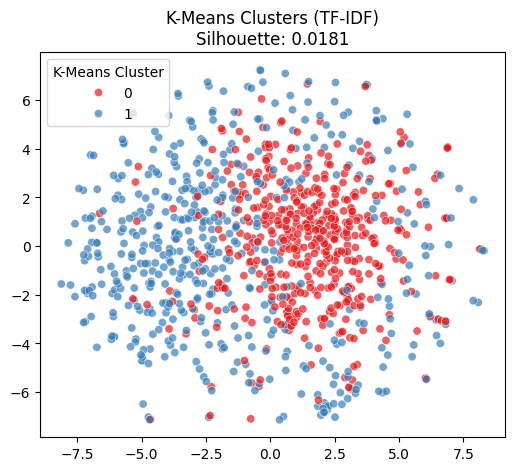

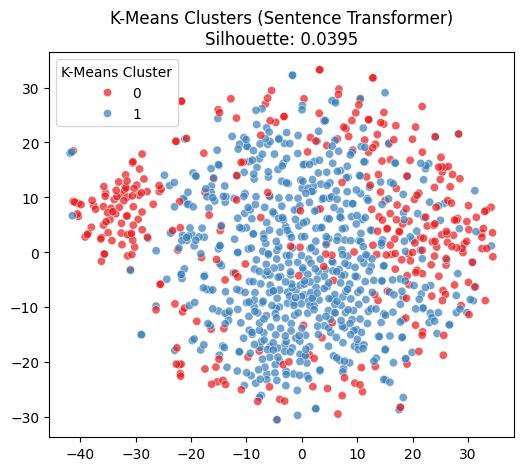

Đang đánh giá Linear SVM...
Linear SVM Accuracy (TF-IDF): 0.7670
Linear SVM Accuracy (Sentence Transformer): 0.7970


In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Tải mô hình Pre-trained và encode
model_st = SentenceTransformer('all-MiniLM-L6-v2')
print("Đang mã hóa văn bản bằng Sentence Transformer...")
# Dùng X_texts và y_labels từ các bước trước
X_st = model_st.encode(X_texts.tolist(), show_progress_bar=True)

# 2. Phân cụm không giám sát (K-Means k=2)
print("\nĐang thực hiện K-Means Clustering...")
kmeans_tfidf = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_tfidf)
sil_kmeans_tfidf = silhouette_score(X_tfidf.toarray(), kmeans_tfidf.labels_)

kmeans_st = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_st)
sil_kmeans_st = silhouette_score(X_st, kmeans_st.labels_)

print(f"K-Means Silhouette (TF-IDF): {sil_kmeans_tfidf:.4f}")
print(f"K-Means Silhouette (Sentence Transformer): {sil_kmeans_st:.4f}\n")

# 3. Vẽ đồ thị biểu diễn các cụm K-Means
def plot_kmeans_clusters(X_data, cluster_labels, title):
    # Dùng t-SNE để giảm chiều dữ liệu về 2D cho việc vẽ hình
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_dense = X_data.toarray() if hasattr(X_data, "toarray") else X_data
    X_2d = tsne.fit_transform(X_dense)
    
    plt.figure(figsize=(6, 5))
    # Tô màu theo nhãn cụm mà K-Means dự đoán được (0 và 1)
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=cluster_labels, palette='Set1', alpha=0.7)
    plt.title(title)
    plt.legend(title='K-Means Cluster')
    plt.show()

print("Đang vẽ đồ thị các cụm K-Means...")
plot_kmeans_clusters(X_tfidf, kmeans_tfidf.labels_, f"K-Means Clusters (TF-IDF)\nSilhouette: {sil_kmeans_tfidf:.4f}")
plot_kmeans_clusters(X_st, kmeans_st.labels_, f"K-Means Clusters (Sentence Transformer)\nSilhouette: {sil_kmeans_st:.4f}")

# 4. Phân loại có giám sát (Linear SVM)
print("Đang đánh giá Linear SVM...")
svm_tfidf = LinearSVC(random_state=42)
acc_tfidf = np.mean(cross_val_score(svm_tfidf, X_tfidf, y_labels, cv=5))

svm_st = LinearSVC(random_state=42)
acc_st = np.mean(cross_val_score(svm_st, X_st, y_labels, cv=5))

print(f"Linear SVM Accuracy (TF-IDF): {acc_tfidf:.4f}")
print(f"Linear SVM Accuracy (Sentence Transformer): {acc_st:.4f}")